Read downloaded Hazel results

Set `RUNS` to the extracted result folder. This notebook reads completed outputs and never launches training. Partial pilot results are explicitly identified. No figures/tables are saved until the final export cell is enabled.

In [2]:
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt
from hazel_gp.results import (load_results, lolo_report, plot_parity,
                              plot_lolo_comparison, grouped_predictions)

ROOT = Path.cwd().resolve()
RUNS = ROOT / "data_hazel/returned/experiment_v1"
# For a pilot, point RUNS to its extracted folder instead.
tables, collection = load_results(RUNS)
print("Complete benchmark:", collection["complete"])
print("Completed tasks:", collection["completed_tasks"], "/", collection["expected_tasks"])
display(tables["summary"])

Complete benchmark: True
Completed tasks: 110 / 110


,model,method,completed_fits,expected_fits,complete_method,run_complete,aggregation,r2,rmse,mae,...,mean_predictive_std,pit_cdf_mae,abs_residual_std_spearman,coverage_50,width_50,coverage_80,width_80,coverage_95,width_95,n_test
0,ligand_ohe,lolo,8,8,True,True,mean_split_metrics,0.559063,18.875664,14.056842,...,9.565117,0.110993,-0.151413,0.328125,12.903147,0.586263,24.516383,0.755534,37.494572,
1,ligand_ohe,lolo,8,8,True,True,pooled_predictions,0.593420,19.189805,14.056842,...,9.565117,0.077707,-0.049358,0.328125,12.903147,0.586263,24.516383,0.755534,37.494572,3072.0
2,ligand_ohe,iid_matched,8,8,True,True,mean_split_metrics,0.895885,9.674176,7.149265,...,8.728564,0.019385,0.067810,0.537435,11.774654,0.794271,22.372211,0.921549,34.215343,
3,ligand_ohe,iid_matched,8,8,True,True,pooled_predictions,0.896407,9.686411,7.149265,...,8.728564,0.011331,0.050648,0.537435,11.774654,0.794271,22.372211,0.921549,34.215343,3072.0
4,ligand_ohe,kfold,5,5,True,True,mean_split_metrics,0.893299,9.811362,7.249898,...,8.945242,0.021518,0.036291,0.537435,12.066949,0.807946,22.927579,0.927740,35.064706,
5,ligand_ohe,kfold,5,5,True,True,pooled_predictions,0.893626,9.815581,7.249936,...,8.945239,0.010992,0.030710,0.537435,12.066943,0.807943,22.927569,0.927734,35.064691,3072.0
6,ligand_ohe,holdout,1,1,True,True,mean_split_metrics,0.884388,10.058045,7.388119,...,8.896252,0.021544,0.079037,0.539837,12.000861,0.801626,22.802011,0.913821,34.872666,
7,ligand_ohe,holdout,1,1,True,True,pooled_predictions,0.884388,10.058045,7.388119,...,8.896252,0.021544,0.079037,0.539837,12.000861,0.801626,22.802011,0.913821,34.872666,615.0
8,selected_5,lolo,8,8,True,True,mean_split_metrics,0.455396,21.217371,18.609081,...,24.711474,0.100290,-0.005095,0.478190,33.335272,0.871419,63.338057,0.983724,96.867199,
9,selected_5,lolo,8,8,True,True,pooled_predictions,0.454110,22.235666,18.609081,...,24.711474,0.022824,0.443682,0.478190,33.335272,0.871419,63.338057,0.983724,96.867199,3072.0


### Inspect predictions
Use the dropdowns to select model, evaluation method, and reference ligand. For matched IID, a reference ligand labels the size-matching comparison; its test set contains multiple ligands.

In [3]:
from hazel_gp.notebook import review_controls
display(review_controls(tables))

### LOLO reported three ways
`lolo_report` returns each held-out ligand on its own, the unweighted mean across the eight ligand-left-out models, and the pooled score after all eight folds. Pooled and averaged values are not interchangeable: pooled R² is measured against the variance of the whole dataset, a per-ligand R² against the variance within that one ligand, so the averaged value is systematically harsher.

Matched IID now uses the same eight-fold geometry with random membership, so its pooled score is the like-for-like in-distribution comparison.

,model,view,scope,n_test,r2,rmse,mae,kendall_tau
0,ligand_ohe,per_ligand,AmPhos,384.0,0.808,13.851,10.338,0.6943743694638684
1,ligand_ohe,per_ligand,CataCXium A,384.0,0.742,15.711,12.158,0.6800301907144318
2,ligand_ohe,per_ligand,P(Cy)3,384.0,0.743,15.003,11.305,0.6734031945473381
3,ligand_ohe,per_ligand,P(Ph)3,384.0,0.652,19.611,15.072,0.6241806086331863
4,ligand_ohe,per_ligand,P(o-Tol)3,384.0,0.423,20.853,16.020,0.5962096868779311
5,ligand_ohe,per_ligand,P(tBu)3,384.0,0.509,20.246,14.432,0.6123309392150823
6,ligand_ohe,per_ligand,SPhos,384.0,0.436,20.961,14.821,0.6084697827639556
7,ligand_ohe,per_ligand,XPhos,384.0,0.159,24.769,18.308,0.520212977777042
8,ligand_ohe,mean_across_ligands,8 ligands,NaN,0.559,18.876,14.057,0.626151
9,ligand_ohe,pooled_over_folds,8 folds,3072.0,0.593,19.190,14.057,0.597694


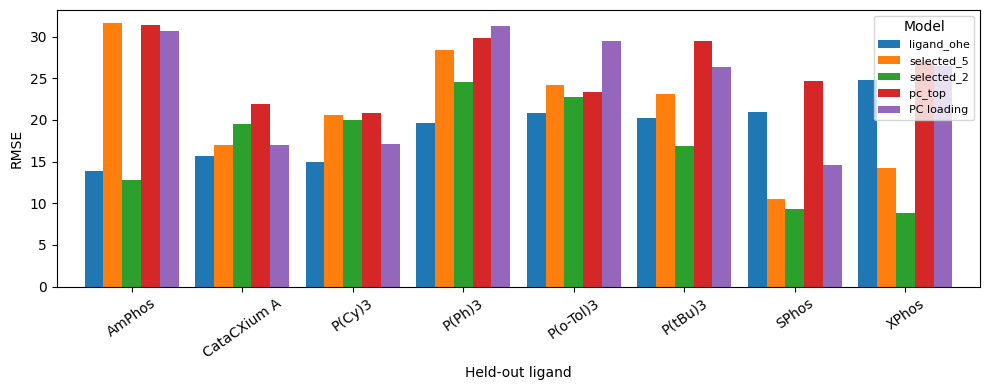

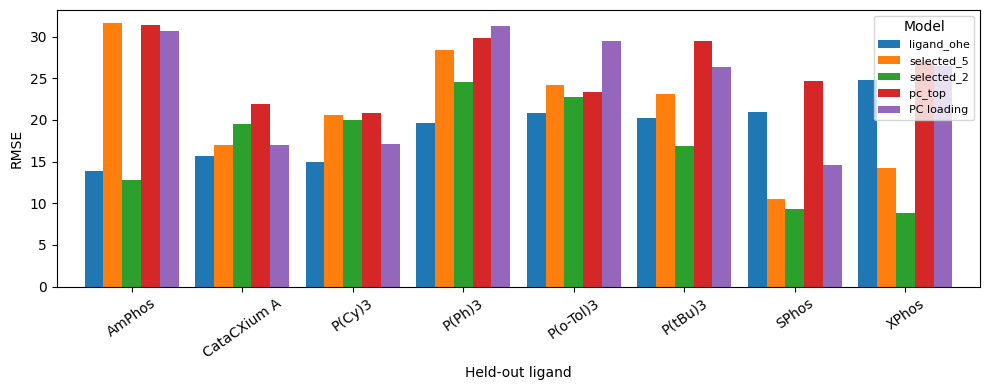

In [4]:
METRIC = "rmse"
report = lolo_report(tables["predictions"], tables["metrics_by_split"])
display(report[["model", "view", "scope", "n_test", "r2", "rmse", "mae", "kendall_tau"]].round(3))

fig_ligands = plot_lolo_comparison(tables["metrics_by_split"], metric=METRIC)
display(fig_ligands)

### Grouped arrays, if needed
Seeds are recorded in the split metadata; arrays are stored as lists per reference group.

In [ ]:
grouped_iid = grouped_predictions(tables["predictions"], model="selected_2", method="iid_matched")
print("Reference groups:", list(grouped_iid))
# Example after the IID tasks have completed:
#grouped_iid["SPhos"]["y_pred"]

Reference groups: ['']


KeyError: 'SPhos'

### Final export
Set `SAVE = True`, choose a **new** output folder, select the formats/tables, and execute this cell. Existing destinations are protected.

In [ ]:
SAVE = False
EXPORT_DIR = ROOT / "exports/local_review_v1"
FIGURE_FORMATS = ["png", "pdf"]
TABLES_TO_SAVE = ["summary", "metrics_by_split", "predictions"]

if SAVE:
    EXPORT_DIR.mkdir(parents=True, exist_ok=False)
    for name in TABLES_TO_SAVE:
        tables[name].to_csv(EXPORT_DIR / f"{name}.csv", index=False)
    report.to_csv(EXPORT_DIR / "lolo_report.csv", index=False)
    for name, fig in {"lolo_by_ligand": fig_ligands}.items():
        for fmt in FIGURE_FORMATS:
            fig.savefig(EXPORT_DIR / f"{name}.{fmt}", dpi=300, bbox_inches="tight")
    print("Saved:", EXPORT_DIR)
else:
    print("Preview only. Set SAVE=True when ready.")